# NALAPRO Final Project - Naa Lamiorkor Boye

## Installing and Importing Libraries and Dataset

In [34]:
!pip install numpy pandas matplotlib scikit-learn nltk gensim torch transformers datasets

In [71]:
# Core libraries
import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')

# Sklearn
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Gensim
from gensim.models import Word2Vec

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


from collections import Counter

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/LamiorkorBoye/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/LamiorkorBoye/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Preliminary Look at Data

In [36]:
# Storing the training and testing sets of the data, and setting X and y variables   
train_data = fetch_20newsgroups(subset='train')
test_data = fetch_20newsgroups(subset='test')

X_train = train_data.data
y_train = train_data.target

X_test = test_data.data
y_test = test_data.target

In [37]:
# Displaying key information about the dataset

print("Number of training documents:", len(X_train))
print("Number of test documents:", len(X_test))
print("Number of classes:", len(train_data.target_names))
print("Class names:", train_data.target_names)

Number of training documents: 11314
Number of test documents: 7532
Number of classes: 20
Class names: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [38]:
# Displaying a sample document from the training set

print("\nSample document:\n")
print(X_train[0])


Sample document:

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [123]:
print(X_train[1])

A fair number of brave souls who upgraded their SI clock oscillator have
shared their experiences for this poll. Please send a brief message detailing
your experiences with the procedure. Top speed attained, CPU rated speed,
add on cards and adapters, heat sinks, hour of usage per day, floppy disk
functionality with 800 and 1.4 m floppies are especially requested.

I will be summarizing in the next two days, so please add to the network
knowledge base if you have done the clock upgrade and haven't answered this
poll. Thanks.


In [126]:
# Displaying the label and category of the sample document

print("Label index:", y_train[0])
print("Category:", train_data.target_names[y_train[0]])

Label index: 7
Category: rec.autos


In [127]:
# Displaying the distribution of classes in the training set

print("Class distribution:\n")
label_counts = Counter(y_train)
for label, count in sorted(label_counts.items()):
    print(train_data.target_names[label], ":", count)

Class distribution:

alt.atheism : 480
comp.graphics : 584
comp.os.ms-windows.misc : 591
comp.sys.ibm.pc.hardware : 590
comp.sys.mac.hardware : 578
comp.windows.x : 593
misc.forsale : 585
rec.autos : 594
rec.motorcycles : 598
rec.sport.baseball : 597
rec.sport.hockey : 600
sci.crypt : 595
sci.electronics : 591
sci.med : 594
sci.space : 593
soc.religion.christian : 599
talk.politics.guns : 546
talk.politics.mideast : 564
talk.politics.misc : 465
talk.religion.misc : 377


## 1.a Pre-Processing the Data

In [41]:
# Preprocessing the data by removing headers, footers, and quotes

train_data = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

test_data = fetch_20newsgroups(
    subset='test',
    remove=('headers', 'footers', 'quotes')
)

X_train = train_data.data
y_train = train_data.target
X_test = test_data.data
y_test = test_data.target

In [42]:
# Preprocessing function to clean and tokenize the text data

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # lowercase
    text = text.lower()
    
    # remove numbers
    text = re.sub(r'\d+', ' ', text)
    
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # tokenize
    tokens = word_tokenize(text)
    
    # keep only alphabetic words and remove stopwords
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    
    return tokens

In [44]:
# Preprocessing the training and testing data

X_train_tokens = [preprocess_text(doc) for doc in X_train]
X_test_tokens = [preprocess_text(doc) for doc in X_test]

In [45]:
# Displaying the original and preprocessed versions of a sample document

print("Original text:")
print(X_train[0][:500])

print("\nTokenized and cleaned (First 10 tokens):")
print(X_train_tokens[0][:10])

Original text:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Tokenized and cleaned (First 10 tokens):
['wondering', 'anyone', 'could', 'enlighten', 'car', 'saw', 'day', 'door', 'sports', 'car']


In [46]:
# Checking for empty documents after preprocessing

empty_train = sum(1 for doc in X_train_tokens if len(doc) == 0)
empty_test = sum(1 for doc in X_test_tokens if len(doc) == 0)

print("Empty training documents:", empty_train)
print("Empty test documents:", empty_test)

Empty training documents: 314
Empty test documents: 230


In [47]:
# Creating cleaned text strings for TF-IDF later

X_train_clean = [' '.join(tokens) for tokens in X_train_tokens]
X_test_clean = [' '.join(tokens) for tokens in X_test_tokens]

## 1.b Word2Vec
Number of Epochs tried: 1, 3, 5, 10, 20

In [48]:
# 1 Epoch Word2Vec model

w2v_1 = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=1,
    sg=1,
    epochs=1
)

print("Vocabulary size (1 epoch):", len(w2v_1.wv))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary size (1 epoch): 41086


In [49]:
print("Most similar to 'car' (1 epoch):")
print(w2v_1.wv.most_similar("car", topn=10))

print("\nMost similar to 'computer' (1 epoch):")
print(w2v_1.wv.most_similar("computer", topn=10))

print("\nMost similar to 'hockey' (1 epoch):")
print(w2v_1.wv.most_similar("hockey", topn=10))

Most similar to 'car' (1 epoch):
[('still', 0.9936642646789551), ('side', 0.9935705065727234), ('least', 0.9933494329452515), ('little', 0.9930230975151062), ('bad', 0.9929658770561218), ('weve', 0.9927783608436584), ('bike', 0.9926469922065735), ('came', 0.9916767477989197), ('around', 0.9914905428886414), ('almost', 0.9912844300270081)]

Most similar to 'computer' (1 epoch):
[('systems', 0.9907833933830261), ('access', 0.987195611000061), ('user', 0.9848523736000061), ('transfer', 0.9843425154685974), ('applications', 0.9812139868736267), ('includes', 0.9809758067131042), ('network', 0.9804848432540894), ('jpeg', 0.9798211455345154), ('users', 0.9795131683349609), ('unix', 0.9792649149894714)]

Most similar to 'hockey' (1 epoch):
[('nhl', 0.9937886595726013), ('league', 0.9934898614883423), ('russian', 0.989907443523407), ('third', 0.9895792603492737), ('sunday', 0.9894254207611084), ('flames', 0.9893684387207031), ('white', 0.9890403151512146), ('teams', 0.9885376691818237), ('cup',

In [50]:
# 3 Epoch Word2Vec model

w2v_3 = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=1,
    sg=1,
    epochs=3
)

print("Vocabulary size (3 epochs):", len(w2v_3.wv))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary size (3 epochs): 41086


In [51]:
print("Most similar to 'car' (3 epochs):")
print(w2v_3.wv.most_similar("car", topn=10))

print("\nMost similar to 'computer' (3 epochs):")
print(w2v_3.wv.most_similar("computer", topn=10))

print("\nMost similar to 'hockey' (3 epochs):")
print(w2v_3.wv.most_similar("hockey", topn=10))

Most similar to 'car' (3 epochs):
[('cars', 0.8949348330497742), ('tires', 0.8906838893890381), ('dealer', 0.890513002872467), ('bike', 0.8891010284423828), ('bikes', 0.8842554688453674), ('oil', 0.881527841091156), ('miles', 0.8712103366851807), ('garage', 0.8659012913703918), ('owner', 0.8655350208282471), ('rear', 0.8575044870376587)]

Most similar to 'computer' (3 epochs):
[('electrical', 0.8798527121543884), ('network', 0.8622964024543762), ('engineering', 0.8609422445297241), ('tech', 0.8556785583496094), ('digital', 0.8550031185150146), ('engineer', 0.8468175530433655), ('technologies', 0.8437578082084656), ('lab', 0.8400933146476746), ('computers', 0.8355564475059509), ('highspeed', 0.8335356116294861)]

Most similar to 'hockey' (3 epochs):
[('nhl', 0.9627850651741028), ('league', 0.9435310363769531), ('playoff', 0.9293609261512756), ('espn', 0.9223808646202087), ('cup', 0.9136058688163757), ('sports', 0.9124977588653564), ('teams', 0.9119343161582947), ('scores', 0.91029161214

In [52]:
# 5 Epoch Word2Vec model

w2v_5 = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=1,
    sg=1,
    epochs=5
)

print("Vocabulary size (5 epochs):", len(w2v_5.wv))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary size (5 epochs): 41086


In [53]:
print("Most similar to 'car' (5 epochs):")
print(w2v_5.wv.most_similar("car", topn=10))

print("\nMost similar to 'computer' (5 epochs):")
print(w2v_5.wv.most_similar("computer", topn=10))

print("\nMost similar to 'hockey' (5 epochs):")
print(w2v_5.wv.most_similar("hockey", topn=10))

Most similar to 'car' (5 epochs):
[('tires', 0.8298385143280029), ('ford', 0.8169402480125427), ('bikes', 0.8154175877571106), ('cars', 0.8136965036392212), ('porsche', 0.7995679974555969), ('bike', 0.7946323752403259), ('dealership', 0.7940378189086914), ('dealer', 0.78972327709198), ('taurus', 0.7844018936157227), ('toyota', 0.7834606170654297)]

Most similar to 'computer' (5 epochs):
[('electronic', 0.7347692251205444), ('engineering', 0.7312641143798828), ('dgree', 0.7280644178390503), ('programmer', 0.7262023687362671), ('tech', 0.7235566973686218), ('engineer', 0.718744695186615), ('technician', 0.7184468507766724), ('transmits', 0.7145225405693054), ('shopper', 0.7141990661621094), ('technologies', 0.7125706672668457)]

Most similar to 'hockey' (5 epochs):
[('nhl', 0.8607630729675293), ('leagues', 0.8482186198234558), ('allstar', 0.8454093933105469), ('basketball', 0.8445171117782593), ('football', 0.8399316072463989), ('junior', 0.8331260681152344), ('fame', 0.833041787147522),

In [54]:
# 10 Epoch Word2Vec model

w2v_10 = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=1,
    sg=1,
    epochs=10
)

print("Vocabulary size (10 epochs):", len(w2v_10.wv))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary size (10 epochs): 41086


In [55]:
print("Most similar to 'car' (10 epochs):")
print(w2v_10.wv.most_similar("car", topn=10))

print("\nMost similar to 'computer' (10 epochs):")
print(w2v_10.wv.most_similar("computer", topn=10))

print("\nMost similar to 'hockey' (10 epochs):")
print(w2v_10.wv.most_similar("hockey", topn=10))

Most similar to 'car' (10 epochs):
[('cars', 0.7346920967102051), ('porsche', 0.7121949791908264), ('volvo', 0.7085365653038025), ('noises', 0.7029602527618408), ('taurus', 0.7009029388427734), ('truck', 0.6952828168869019), ('maxima', 0.6836609244346619), ('gtz', 0.6829634308815002), ('tires', 0.6814722418785095), ('dealership', 0.6801443696022034)]

Most similar to 'computer' (10 epochs):
[('dgree', 0.6653828620910645), ('usnos', 0.6508360505104065), ('aided', 0.6490433216094971), ('shopper', 0.6328597068786621), ('computers', 0.6322313547134399), ('doublemajor', 0.6095139980316162), ('architecture', 0.6090769171714783), ('technologys', 0.6078019738197327), ('rigs', 0.5978217124938965), ('electronic', 0.5977548360824585)]

Most similar to 'hockey' (10 epochs):
[('basketball', 0.735134482383728), ('nhl', 0.7323083877563477), ('teams', 0.7277544140815735), ('ncaa', 0.7277141809463501), ('champions', 0.7106127738952637), ('chl', 0.701529324054718), ('tournament', 0.7002319693565369), ('

In [56]:
# 20 Epoch Word2Vec model

w2v_20 = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=1,
    sg=1,
    epochs=20
)

print("Vocabulary size (20 epochs):", len(w2v_20.wv))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Vocabulary size (20 epochs): 41086


In [57]:
print("Most similar to 'car' (20 epochs):")
print(w2v_20.wv.most_similar("car", topn=10))

print("\nMost similar to 'computer' (20 epochs):")
print(w2v_20.wv.most_similar("computer", topn=10))

print("\nMost similar to 'hockey' (20 epochs):")
print(w2v_20.wv.most_similar("hockey", topn=10))

Most similar to 'car' (20 epochs):
[('cars', 0.7193800806999207), ('sentra', 0.7087622880935669), ('purring', 0.7020394802093506), ('towed', 0.6996628046035767), ('gtz', 0.6986199617385864), ('audi', 0.6979179978370667), ('noises', 0.6907972693443298), ('tranny', 0.6890268325805664), ('impreza', 0.6862735152244568), ('gsr', 0.6802863478660583)]

Most similar to 'computer' (20 epochs):
[('usnos', 0.6697920560836792), ('dgree', 0.6539334058761597), ('aided', 0.6440859436988831), ('doublemajor', 0.6309763789176941), ('metronome', 0.6309289336204529), ('hardwaresoftware', 0.6206113696098328), ('rutgers', 0.6204308271408081), ('computers', 0.6192459464073181), ('shopper', 0.6182625889778137), ('amann', 0.6162517666816711)]

Most similar to 'hockey' (20 epochs):
[('ncaa', 0.7008605599403381), ('monicker', 0.6842940449714661), ('playoff', 0.6837457418441772), ('nhl', 0.6800774335861206), ('affiliates', 0.6792802214622498), ('televise', 0.6749159097671509), ('harlem', 0.6734098792076111), ('pe

In [58]:
# Visualization function to plot word vectors using PCA

def plot_word_vectors(model, words, title):
    valid_words = [word for word in words if word in model.wv]
    vectors = [model.wv[word] for word in valid_words]

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 8))
    plt.scatter(reduced[:, 0], reduced[:, 1])

    for i, word in enumerate(valid_words):
        plt.annotate(word, (reduced[i, 0], reduced[i, 1]))

    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

In [59]:
words_to_plot = [
    "car", "cars", "engine", "ford", "dealer",
    "computer", "software", "graphics", "windows", "file",
    "hockey", "nhl", "baseball", "team", "season",
    "god", "religion", "christian", "church", "faith"
]

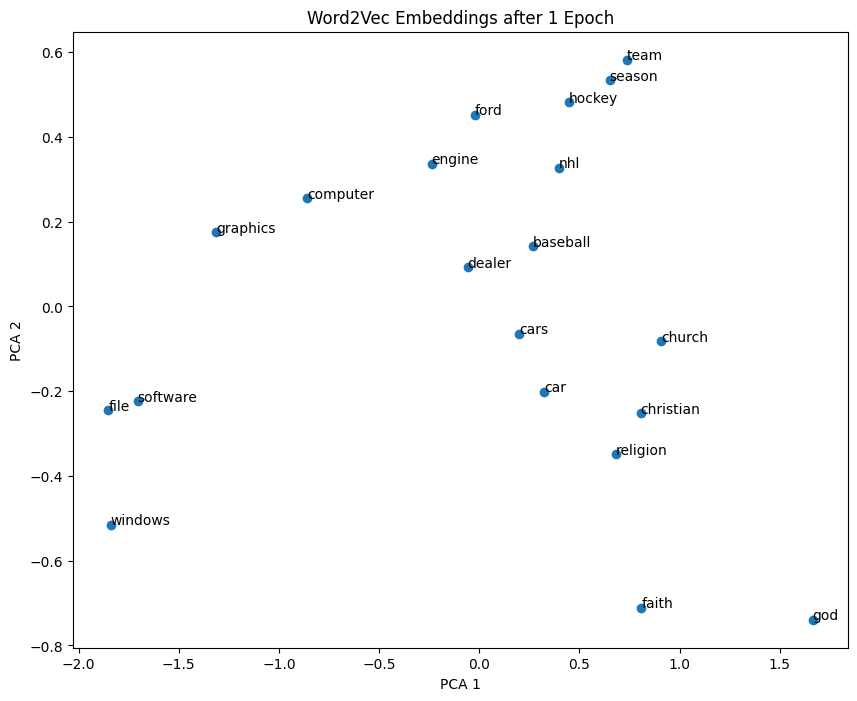

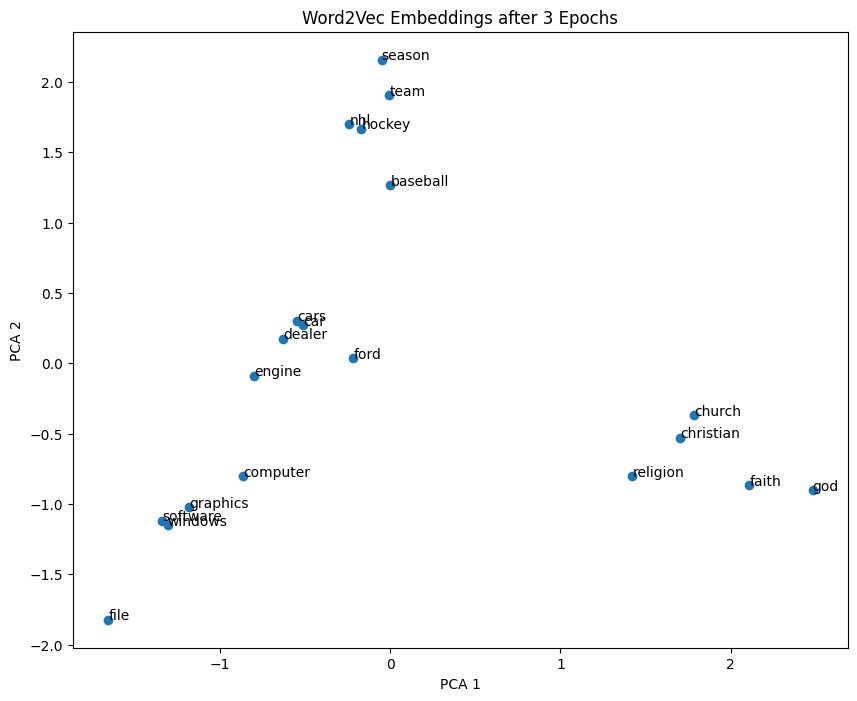

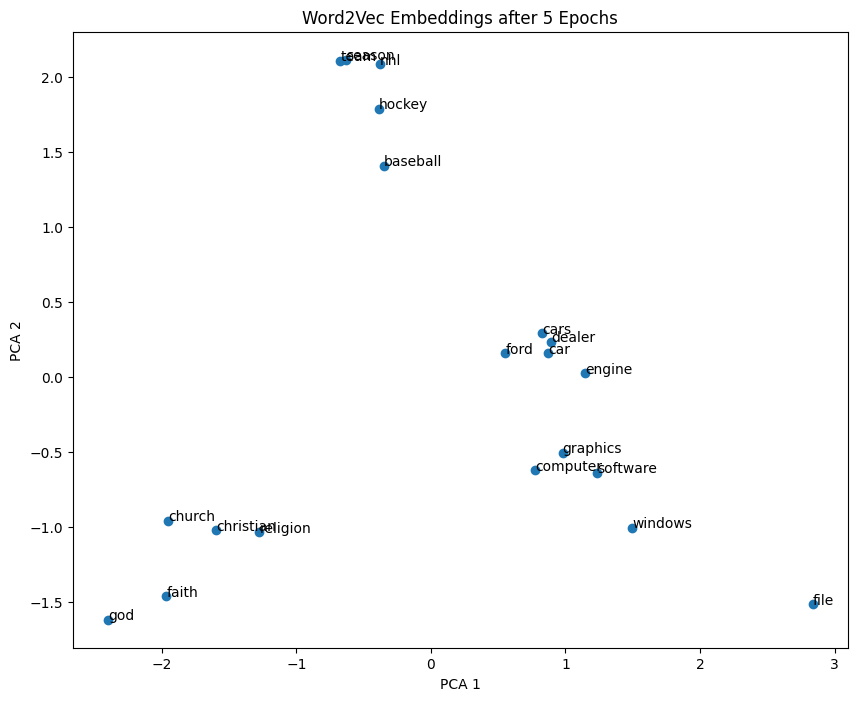

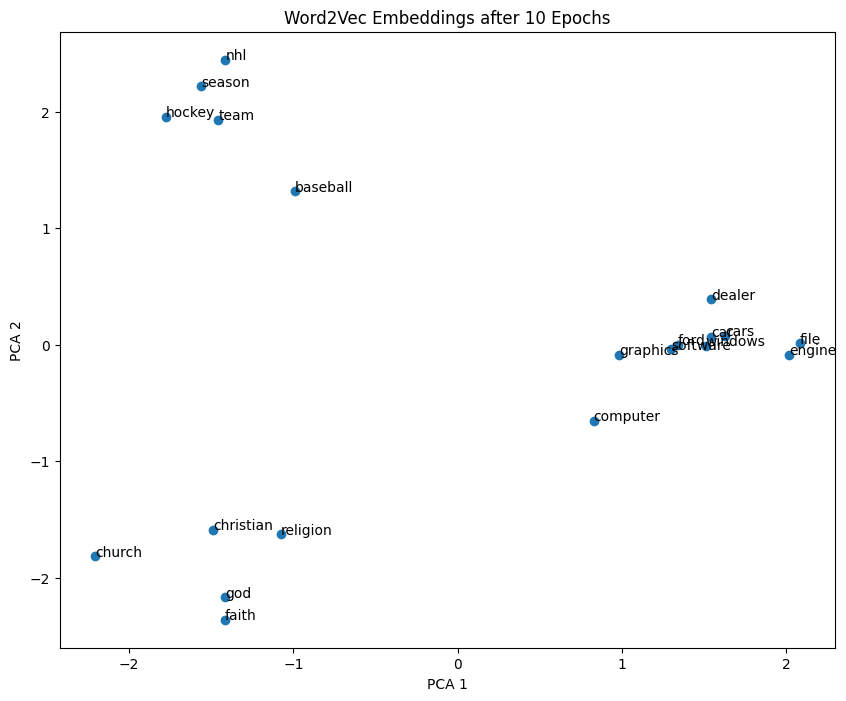

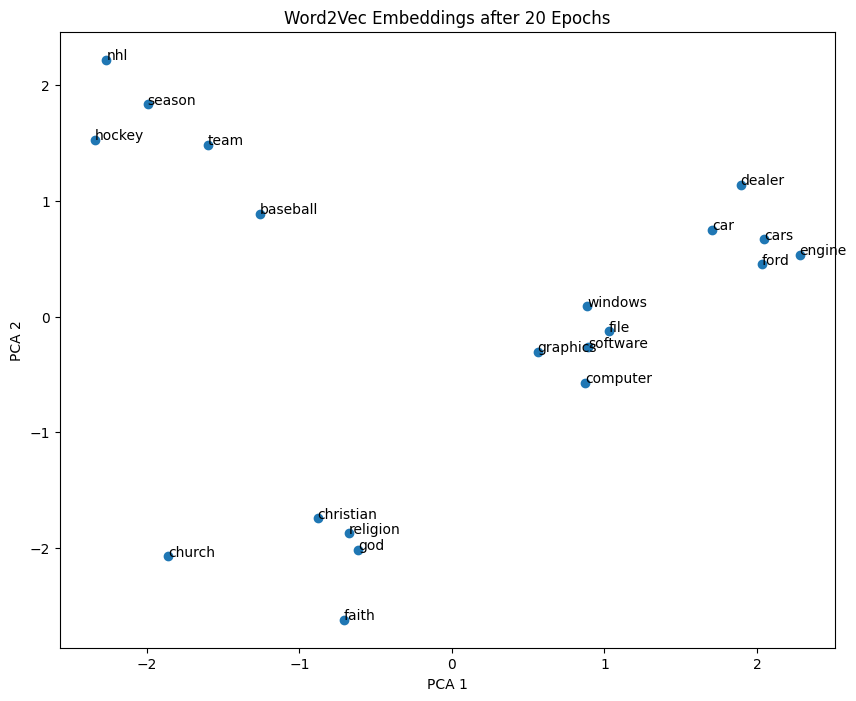

In [60]:
plot_word_vectors(w2v_1, words_to_plot, "Word2Vec Embeddings after 1 Epoch")
plot_word_vectors(w2v_3, words_to_plot, "Word2Vec Embeddings after 3 Epochs")
plot_word_vectors(w2v_5, words_to_plot, "Word2Vec Embeddings after 5 Epochs")
plot_word_vectors(w2v_10, words_to_plot, "Word2Vec Embeddings after 10 Epochs")
plot_word_vectors(w2v_20, words_to_plot, "Word2Vec Embeddings after 20 Epochs")

In [66]:
# Function to compute document vectors by averaging word vectors

def document_vector(model, doc_tokens):
    word_vectors = [model.wv[word] for word in doc_tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(word_vectors, axis=0)

In [67]:
# Creating a dictionary to store the different Word2Vec models for easy access

w2v_models = {
    1: w2v_1,
    3: w2v_3,
    5: w2v_5,
    10: w2v_10,
    20: w2v_20
}

In [68]:
# Storing all the document vectors in dictionaries for easier access

X_train_vectors = {}
X_test_vectors = {}

for epoch, model in w2v_models.items():
    X_train_vectors[epoch] = np.array([document_vector(model, doc) for doc in X_train_tokens])
    X_test_vectors[epoch] = np.array([document_vector(model, doc) for doc in X_test_tokens])
    
    print(f"Epoch {epoch}:")
    print("Train shape:", X_train_vectors[epoch].shape)
    print("Test shape:", X_test_vectors[epoch].shape)
    print()

Epoch 1:
Train shape: (11314, 100)
Test shape: (7532, 100)

Epoch 3:
Train shape: (11314, 100)
Test shape: (7532, 100)

Epoch 5:
Train shape: (11314, 100)
Test shape: (7532, 100)

Epoch 10:
Train shape: (11314, 100)
Test shape: (7532, 100)

Epoch 20:
Train shape: (11314, 100)
Test shape: (7532, 100)



In [69]:
# Converting labels to PyTorch tensors

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

### Neural Network

In [82]:
# Defining a simple feedforward neural network with two linear layers and a ReLU in between for classification  

class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [83]:
# Training function for the neural network
def train_model(model, train_loader, criterion, optimizer, epochs=10):
        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            
            for inputs, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            
            avg_loss = running_loss / len(train_loader)
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

In [84]:
# Evaluation function to compute accuracy on the test set

def evaluate_model(model, test_loader):
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracy = 100 * correct / total
        return accuracy

In [105]:
results = []

input_dim = 100
hidden_dim = 128
output_dim = 20
batch_size = 64
nn_epochs = 10

criterion = nn.CrossEntropyLoss()

for epoch, X_train_vec in X_train_vectors.items():
    print(f"\nTraining neural network with Word2Vec embeddings from {epoch} epoch(s)...")
    
    X_test_vec = X_test_vectors[epoch]
    
    # Convert features to tensors
    X_train_tensor = torch.tensor(X_train_vec, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_vec, dtype=torch.float32)
    
    # Create datasets and loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Create a fresh model for this experiment
    model = SimpleNN(input_dim, hidden_dim, output_dim)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Train
    train_model(model, train_loader, criterion, optimizer, epochs=nn_epochs)
    
    # Evaluate
    accuracy = evaluate_model(model, test_loader)
    print(f"Test Accuracy for Word2Vec ({epoch} epoch(s)): {accuracy:.2f}%")
    
    # Store result
    results.append({
        "Representation": f"Word2Vec ({epoch} epoch{'s' if epoch > 1 else ''})",
        "NN Test Accuracy (%)": accuracy
    })


Training neural network with Word2Vec embeddings from 1 epoch(s)...
Epoch [1/10], Loss: 2.8672
Epoch [2/10], Loss: 2.5805
Epoch [3/10], Loss: 2.4896
Epoch [4/10], Loss: 2.4460
Epoch [5/10], Loss: 2.4131
Epoch [6/10], Loss: 2.3822
Epoch [7/10], Loss: 2.3507
Epoch [8/10], Loss: 2.3230
Epoch [9/10], Loss: 2.2945
Epoch [10/10], Loss: 2.2710
Test Accuracy for Word2Vec (1 epoch(s)): 26.21%

Training neural network with Word2Vec embeddings from 3 epoch(s)...
Epoch [1/10], Loss: 2.6122
Epoch [2/10], Loss: 2.0425
Epoch [3/10], Loss: 1.8675
Epoch [4/10], Loss: 1.7929
Epoch [5/10], Loss: 1.7453
Epoch [6/10], Loss: 1.7092
Epoch [7/10], Loss: 1.6833
Epoch [8/10], Loss: 1.6589
Epoch [9/10], Loss: 1.6384
Epoch [10/10], Loss: 1.6191
Test Accuracy for Word2Vec (3 epoch(s)): 45.07%

Training neural network with Word2Vec embeddings from 5 epoch(s)...
Epoch [1/10], Loss: 2.5767
Epoch [2/10], Loss: 1.9174
Epoch [3/10], Loss: 1.6941
Epoch [4/10], Loss: 1.5886
Epoch [5/10], Loss: 1.5285
Epoch [6/10], Loss: 

In [106]:
# Creating a DataFrame to display the results in a tabular format

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="NN Test Accuracy (%)").reset_index(drop=True)

print(results_df)

         Representation  NN Test Accuracy (%)
0    Word2Vec (1 epoch)             26.208178
1   Word2Vec (3 epochs)             45.074349
2   Word2Vec (5 epochs)             53.624535
3  Word2Vec (10 epochs)             60.501859
4  Word2Vec (20 epochs)             61.949018


## 1.c TF-IDF 

In [107]:
# Applying TF-IDF vectorization to the cleaned text data for comparison with Word2Vec embeddings

tfidf = TfidfVectorizer(
    max_features=5000,   
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (11314, 5000)
TF-IDF test shape: (7532, 5000)


In [108]:
# Converting TF-IDF features to dense tensors for PyTorch

X_train_tfidf = X_train_tfidf.toarray()
X_test_tfidf = X_test_tfidf.toarray()

X_train_tensor_tfidf = torch.tensor(X_train_tfidf, dtype=torch.float32)
X_test_tensor_tfidf = torch.tensor(X_test_tfidf, dtype=torch.float32)

In [109]:
# Creating datasets and loaders for TF-IDF features  

train_dataset_tfidf = TensorDataset(X_train_tensor_tfidf, y_train_tensor)
test_dataset_tfidf = TensorDataset(X_test_tensor_tfidf, y_test_tensor)

train_loader_tfidf = DataLoader(train_dataset_tfidf, batch_size=64, shuffle=True)
test_loader_tfidf = DataLoader(test_dataset_tfidf, batch_size=64, shuffle=False)

In [110]:
# Training the neural network on TF-IDF features for comparison

input_dim = X_train_tfidf.shape[1] 
hidden_dim = 128
output_dim = 20

model_tfidf = SimpleNN(input_dim, hidden_dim, output_dim)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tfidf.parameters(), lr=0.001)

train_model(model_tfidf, train_loader_tfidf, criterion, optimizer, epochs=10)

accuracy_tfidf = evaluate_model(model_tfidf, test_loader_tfidf)

print(f"Test Accuracy with TF-IDF: {accuracy_tfidf:.2f}%")

Epoch [1/10], Loss: 2.5656
Epoch [2/10], Loss: 1.3805
Epoch [3/10], Loss: 0.8809
Epoch [4/10], Loss: 0.6458
Epoch [5/10], Loss: 0.4964
Epoch [6/10], Loss: 0.3906
Epoch [7/10], Loss: 0.3150
Epoch [8/10], Loss: 0.2592
Epoch [9/10], Loss: 0.2198
Epoch [10/10], Loss: 0.1902
Test Accuracy with TF-IDF: 63.85%


In [115]:
# Storing the TF-IDF result for comparison in the results list

results.append({
    "Representation": "TF-IDF",
    "NN Test Accuracy (%)": accuracy_tfidf
})

results_df = pd.DataFrame(results) 
results_df   

,Representation,NN Test Accuracy (%)
0,Word2Vec (1 epoch),26.208178
1,Word2Vec (3 epochs),45.074349
2,Word2Vec (5 epochs),53.624535
3,Word2Vec (10 epochs),60.501859
4,Word2Vec (20 epochs),61.949018
5,TF-IDF,63.847584


## 1.d Extra Experiment - TF-IDF with N-Grams

In [117]:
# Exploring TF-IDF with n-grams (unigrams + bigrams) to see if it improves performance

tfidf_ngram = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf_ngram = tfidf_ngram.fit_transform(X_train_clean)
X_test_tfidf_ngram = tfidf_ngram.transform(X_test_clean)

print("TF-IDF n-gram train shape:", X_train_tfidf_ngram.shape)
print("TF-IDF n-gram test shape:", X_test_tfidf_ngram.shape)

TF-IDF n-gram train shape: (11314, 10000)
TF-IDF n-gram test shape: (7532, 10000)


In [118]:
# Converting TF-IDF n-gram features to dense tensors for PyTorch

X_train_tfidf_ngram = X_train_tfidf_ngram.toarray()
X_test_tfidf_ngram = X_test_tfidf_ngram.toarray()

X_train_tensor_ngram = torch.tensor(X_train_tfidf_ngram, dtype=torch.float32)
X_test_tensor_ngram = torch.tensor(X_test_tfidf_ngram, dtype=torch.float32)

train_dataset_ngram = TensorDataset(X_train_tensor_ngram, y_train_tensor)
test_dataset_ngram = TensorDataset(X_test_tensor_ngram, y_test_tensor)

train_loader_ngram = DataLoader(train_dataset_ngram, batch_size=64, shuffle=True)
test_loader_ngram = DataLoader(test_dataset_ngram, batch_size=64, shuffle=False)

In [119]:
# Training the neural network on TF-IDF n-gram features for comparison

input_dim = X_train_tfidf_ngram.shape[1]
hidden_dim = 128
output_dim = 20

model_tfidf_ngram = SimpleNN(input_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tfidf_ngram.parameters(), lr=0.001)

train_model(model_tfidf_ngram, train_loader_ngram, criterion, optimizer, epochs=10)
accuracy_tfidf_ngram = evaluate_model(model_tfidf_ngram, test_loader_ngram)

print(f"Test Accuracy with TF-IDF + N-grams: {accuracy_tfidf_ngram:.2f}%")

Epoch [1/10], Loss: 2.5540
Epoch [2/10], Loss: 1.2716
Epoch [3/10], Loss: 0.7351
Epoch [4/10], Loss: 0.4906
Epoch [5/10], Loss: 0.3449
Epoch [6/10], Loss: 0.2546
Epoch [7/10], Loss: 0.1995
Epoch [8/10], Loss: 0.1651
Epoch [9/10], Loss: 0.1441
Epoch [10/10], Loss: 0.1302
Test Accuracy with TF-IDF + N-grams: 66.99%


In [ ]:
results.append({
    "Representation": "TF-IDF (1,2)-grams",
    "NN Test Accuracy (%)": accuracy_tfidf_ngram
})

results_df = pd.DataFrame(results) 
results_df  

,Representation,NN Test Accuracy (%)
0,Word2Vec (1 epoch),26.208178
1,Word2Vec (3 epochs),45.074349
2,Word2Vec (5 epochs),53.624535
3,Word2Vec (10 epochs),60.501859
4,Word2Vec (20 epochs),61.949018
5,TF-IDF,63.847584
6,"TF-IDF (1,2)-grams",66.994158


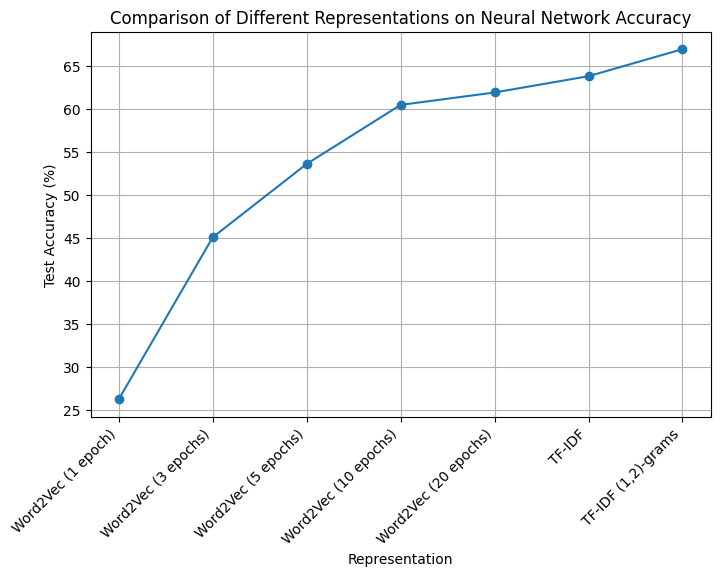

In [122]:
# Plotting the results to visualize the effect of different representations on neural network accuracy

plt.figure(figsize=(8, 5))
plt.plot(results_df["Representation"], results_df["NN Test Accuracy (%)"], marker='o')
plt.title("Comparison of Different Representations on Neural Network Accuracy")
plt.xlabel("Representation")
plt.ylabel("Test Accuracy (%)")
plt.xticks(results_df["Representation"], rotation=45, ha='right')
plt.grid(True)
plt.show()

## Testing Model after removing empty documents

In [132]:
# Function to remove empty documents from the tokenized data and corresponding labels

def remove_empty_docs(X_tokens, X_clean, y):
    X_tokens_new = []
    X_clean_new = []
    y_new = []

    for tokens, clean_text, label in zip(X_tokens, X_clean, y):
        if len(tokens) > 0:
            X_tokens_new.append(tokens)
            X_clean_new.append(clean_text)
            y_new.append(label)

    return X_tokens_new, X_clean_new, y_new

In [133]:
# Removing empty documents from the training and testing sets

X_train_tokens_noempty, X_train_clean_noempty, y_train_noempty = remove_empty_docs(
    X_train_tokens, X_train_clean, y_train
)

X_test_tokens_noempty, X_test_clean_noempty, y_test_noempty = remove_empty_docs(
    X_test_tokens, X_test_clean, y_test
)

print("Train size before removing empty docs:", len(X_train_tokens))
print("Train size after removing empty docs:", len(X_train_tokens_noempty))
print("Test size before removing empty docs:", len(X_test_tokens))
print("Test size after removing empty docs:", len(X_test_tokens_noempty))

Train size before removing empty docs: 11314
Train size after removing empty docs: 11000
Test size before removing empty docs: 7532
Test size after removing empty docs: 7302


In [134]:
# Converting the labels of the non-empty documents to PyTorch tensors for potential use in training or evaluation

y_train_tensor_noempty = torch.tensor(y_train_noempty, dtype=torch.long)
y_test_tensor_noempty = torch.tensor(y_test_noempty, dtype=torch.long)

In [ ]:
# Creating document vectors for the non-empty documents using the 10 and 20 epoch Word2Vec models for comparison with the original vectors that included empty documents

X_train_vec_10_ne = np.array([document_vector(w2v_10, doc) for doc in X_train_tokens_noempty])
X_test_vec_10_ne = np.array([document_vector(w2v_10, doc) for doc in X_test_tokens_noempty])

X_train_vec_20_ne = np.array([document_vector(w2v_20, doc) for doc in X_train_tokens_noempty])
X_test_vec_20_ne = np.array([document_vector(w2v_20, doc) for doc in X_test_tokens_noempty])

In [136]:
def run_nn_experiment(X_train_vec, X_test_vec, y_train_tensor, y_test_tensor):
    X_train_tensor = torch.tensor(X_train_vec, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_vec, dtype=torch.float32)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    model = SimpleNN(input_dim=X_train_vec.shape[1], hidden_dim=128, output_dim=20)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_model(model, train_loader, criterion, optimizer, epochs=10)
    acc = evaluate_model(model, test_loader)

    return acc

In [ ]:
# Running the neural network experiment on the non-empty document vectors from the 10 epoch Word2Vec model and printing the accuracy

acc_w2v10_ne = run_nn_experiment(
    X_train_vec_10_ne, X_test_vec_10_ne,
    y_train_tensor_noempty, y_test_tensor_noempty
)

print(f"Word2Vec (10 epochs, no empty): {acc_w2v10_ne:.2f}%")

Epoch [1/10], Loss: 2.4874
Epoch [2/10], Loss: 1.6839
Epoch [3/10], Loss: 1.4262
Epoch [4/10], Loss: 1.3165
Epoch [5/10], Loss: 1.2530
Epoch [6/10], Loss: 1.2054
Epoch [7/10], Loss: 1.1722
Epoch [8/10], Loss: 1.1477
Epoch [9/10], Loss: 1.1245
Epoch [10/10], Loss: 1.1073
Word2Vec (10 epochs, no empty): 61.93%


In [138]:
# Running the neural network experiment on the non-empty document vectors from the 20 epoch Word2Vec model and printing the accuracy

acc_w2v20_ne = run_nn_experiment(
    X_train_vec_20_ne, X_test_vec_20_ne,
    y_train_tensor_noempty, y_test_tensor_noempty
)

print(f"Word2Vec (20 epochs, no empty): {acc_w2v20_ne:.2f}%")

Epoch [1/10], Loss: 2.4596
Epoch [2/10], Loss: 1.6101
Epoch [3/10], Loss: 1.3227
Epoch [4/10], Loss: 1.1993
Epoch [5/10], Loss: 1.1290
Epoch [6/10], Loss: 1.0837
Epoch [7/10], Loss: 1.0512
Epoch [8/10], Loss: 1.0263
Epoch [9/10], Loss: 1.0054
Epoch [10/10], Loss: 0.9875
Word2Vec (20 epochs, no empty): 64.39%


In [ ]:
# Applying TF-IDF vectorization with n-grams to the non-empty cleaned text data for comparison with the original TF-IDF vectors that included empty documents

tfidf_ngram_ne = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1,2),
    sublinear_tf=True
)

X_train_tfidf_ne = tfidf_ngram_ne.fit_transform(X_train_clean_noempty)
X_test_tfidf_ne = tfidf_ngram_ne.transform(X_test_clean_noempty)

In [140]:
X_train_tfidf_ne = X_train_tfidf_ne.toarray()
X_test_tfidf_ne = X_test_tfidf_ne.toarray()

acc_tfidf_ne = run_nn_experiment(
    X_train_tfidf_ne, X_test_tfidf_ne,
    y_train_tensor_noempty, y_test_tensor_noempty
)

print(f"TF-IDF (1,2)-grams (no empty): {acc_tfidf_ne:.2f}%")

Epoch [1/10], Loss: 2.5342
Epoch [2/10], Loss: 1.2223
Epoch [3/10], Loss: 0.6761
Epoch [4/10], Loss: 0.4260
Epoch [5/10], Loss: 0.2759
Epoch [6/10], Loss: 0.1819
Epoch [7/10], Loss: 0.1240
Epoch [8/10], Loss: 0.0879
Epoch [9/10], Loss: 0.0655
Epoch [10/10], Loss: 0.0507
TF-IDF (1,2)-grams (no empty): 68.90%


In [142]:
result_noempty = []

result_noempty.append({
    "Representation": "Word2Vec (10 epochs, no empty)",
    "NN Test Accuracy (%)": acc_w2v10_ne
})

result_noempty.append({
    "Representation": "Word2Vec (20 epochs, no empty)",
    "NN Test Accuracy (%)": acc_w2v20_ne
})

result_noempty.append({
    "Representation": " TF-IDF n-grams(no empty)",
    "NN Test Accuracy (%)": acc_tfidf_ne
})

results_noempty_df = pd.DataFrame(result_noempty)
results_noempty_df = results_noempty_df.sort_values(by="NN Test Accuracy (%)")

In [145]:
print(results_noempty_df)

                   Representation  NN Test Accuracy (%)
0  Word2Vec (10 epochs, no empty)             61.928239
1  Word2Vec (20 epochs, no empty)             64.393317
2        TF-IDF n-grams(no empty)             68.898932


In [147]:
final_combined_df = pd.concat([results_df, results_noempty_df], ignore_index=True)
final_combined_df = final_combined_df.sort_values(by="NN Test Accuracy (%)").reset_index(drop=True)

print(final_combined_df)

                   Representation  NN Test Accuracy (%)
0              Word2Vec (1 epoch)             26.208178
1             Word2Vec (3 epochs)             45.074349
2             Word2Vec (5 epochs)             53.624535
3            Word2Vec (10 epochs)             60.501859
4  Word2Vec (10 epochs, no empty)             61.928239
5            Word2Vec (20 epochs)             61.949018
6                          TF-IDF             63.847584
7  Word2Vec (20 epochs, no empty)             64.393317
8              TF-IDF (1,2)-grams             66.994158
9        TF-IDF n-grams(no empty)             68.898932


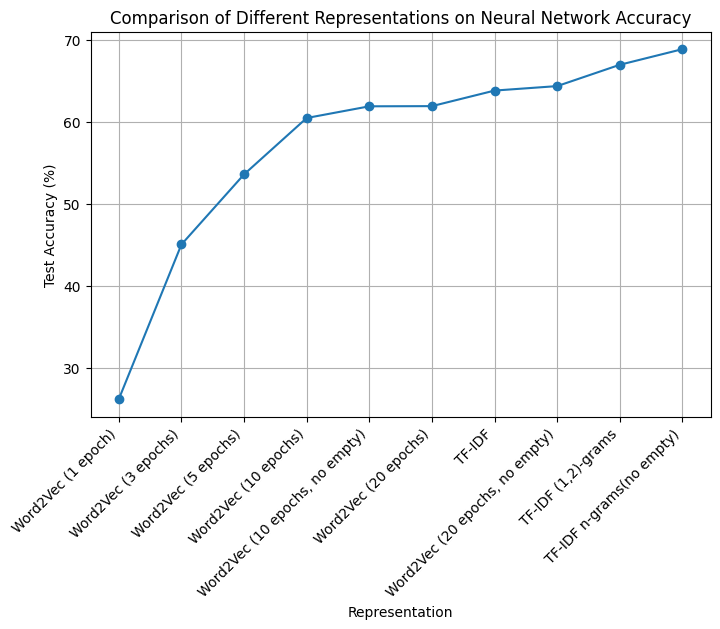

In [148]:
plt.figure(figsize=(8, 5))
plt.plot(final_combined_df["Representation"], final_combined_df["NN Test Accuracy (%)"], marker='o')
plt.title("Comparison of Different Representations on Neural Network Accuracy")
plt.xlabel("Representation")
plt.ylabel("Test Accuracy (%)")
plt.xticks(final_combined_df["Representation"], rotation=45, ha='right')
plt.grid(True)
plt.show()